## Authorship

- **Course / code author:** Xinze Li  
- **Tutorial article:** Xinze Li, Fanfan Lin, Juan J. Rodríguez-Andina, Sergio Vazquez, Homer Alan Mantooth, Leopoldo García Franquelo, "Fundamentals of Artificial Intelligences for Power Electronics," *IEEE Transactions on Industrial Electronics*, 2026.

*These learning resources are still under active refinement; notebooks, data, and documentation may change.*

---



Tutorial of Multi-Objective Optimization Algorithms
 * Deterministic non-dominated sorting
 * Non-dominated sorting genetic algorithm (NSGA-II)

In [1]:
%load_ext autoreload
%autoreload 2

#### 1 A Deterministic Algorithm: Non-Dominated Sorting Algorithm
 * Key strategy in population-based multi-objective optimization algorithms, such as NSGA-II, MOPSO
 * It is a deterministic algorithm, and works for discrete variables.

##### 1.1 A Toy Example

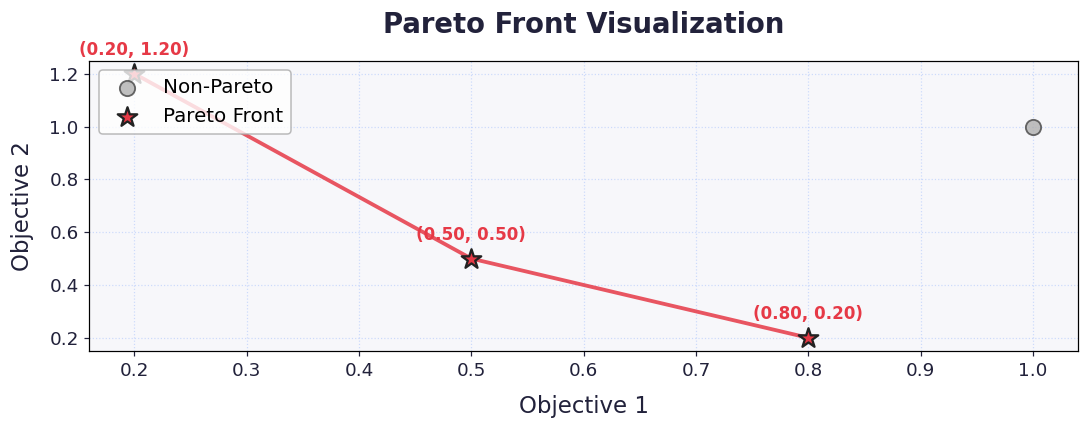

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from paretoset import paretoset

# Define the points
points = np.array([
    [0.5, 0.5],
    [1.0, 1.0],
    [0.8, 0.2],
    [0.2, 1.2]
])

# Find the Pareto front (assuming minimization)
is_pareto = paretoset(points, sense=["min", "min"])
pareto_points = points[is_pareto]
non_pareto_points = points[~is_pareto]

# Enhanced Pareto front visualization

plt.figure(figsize=(10, 4), dpi=110)
ax = plt.gca()

# Draw a subtle background grid with color
ax.set_facecolor('#f7f7fa')
plt.grid(True, linestyle=':', alpha=0.5, zorder=0, color='#a3bffa')  # Added grid color

# Plot non-Pareto points
plt.scatter(
    non_pareto_points[:, 0], non_pareto_points[:, 1],
    color='#b0b0b0', s=100, label='Non-Pareto', alpha=0.8,
    marker='o', edgecolor='#444', linewidth=1.2, zorder=2
)

# Plot Pareto front points
plt.scatter(
    pareto_points[:, 0], pareto_points[:, 1],
    color='#e63946', s=180, label='Pareto Front',
    marker='*', edgecolor='#222', linewidth=1.5, zorder=4
)

# Annotate Pareto points
for i, (x, y) in enumerate(pareto_points):
    plt.annotate(
        f'({x:.2f}, {y:.2f})', (x, y),
        textcoords="offset points", xytext=(0, 12),
        ha='center', fontsize=11, color='#e63946', fontweight='bold', zorder=6
    )

# Connect Pareto points for visual clarity
if len(pareto_points) > 1:
    sorted_pareto = pareto_points[np.argsort(pareto_points[:, 0])]
    plt.plot(
        sorted_pareto[:, 0], sorted_pareto[:, 1],
        color='#e63946', linestyle='-', linewidth=2.5, alpha=0.85, zorder=3
    )

plt.title('Pareto Front Visualization', fontsize=18, fontweight='bold', color='#22223b', pad=18)
plt.xlabel('Objective 1', fontsize=15, labelpad=10, color='#22223b')
plt.ylabel('Objective 2', fontsize=15, labelpad=10, color='#22223b')
plt.tick_params(axis='both', which='major', labelsize=12, colors='#22223b')
plt.legend(fontsize=13, loc='upper left', frameon=True, facecolor='white', edgecolor='#aaa')
plt.tight_layout()
plt.show()


##### 1.2 Benchmark Functions: ZDT-1

The ZDT-1 problem is a widely used benchmark in multi-objective optimization. It is defined as follows:

**Decision Variables:**
- \( x = (x_1, x_2, ..., x_n) \), where \( x_i in [0, 1] \) for \( i = 1, ..., n \) (commonly \( n = 30 \)).

**Objectives:**

\begin{align*}
f_1(x) &= x_1 \\
f_2(x) &= g(x) \left[1 - \sqrt{\frac{x_1}{g(x)}}\right]
\end{align*}


**Properties:**
- The Pareto-optimal front is obtained when \( x_i = 0 \) for \( i = 2, ..., n \), so \( g(x) = 1 \).
- The Pareto front is convex and defined by \( f_2 = 1 - sqrt{f_1} \), with \( f_1 in [0, 1] \).

**Summary of ZDT-1 Algorithm Steps:**
1. Initialize a population of solutions with \( x_i in [0, 1] \).
2. Evaluate \( f_1(x) \) and \( f_2(x) \) for each solution using the formulas above.
3. Apply a multi-objective optimization algorithm (e.g., NSGA-II) to evolve the population toward the Pareto front.
4. The true Pareto front is given by all points \( (f_1, f_2) \) where \( f_2 = 1 - sqrt{f_1} \) and \( f_1 in [0, 1] \).

- In the case of non-dominated sorting algorithm, we consider the dimension to be 2.

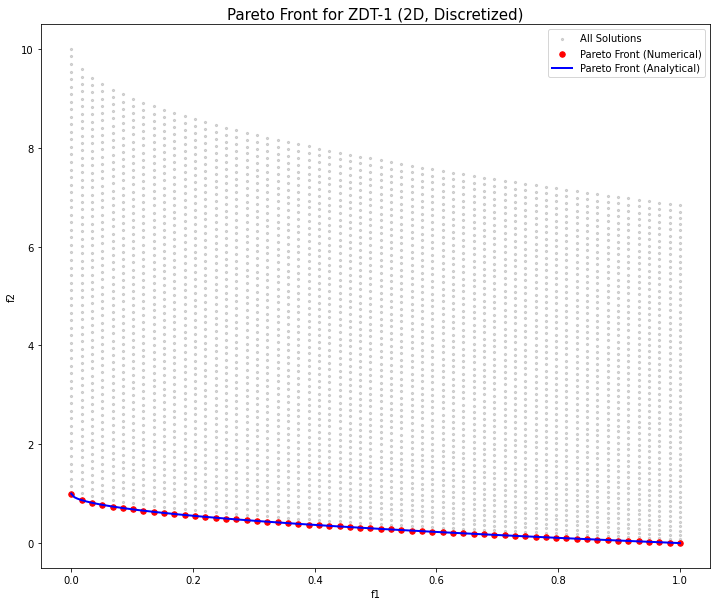

In [3]:
import numpy as np

# ZDT-1 functions for 2-dimensional input
def zdt1_objectives(x):
    # x: array-like, shape (2,)
    f1 = x[0]
    g = 1 + 9 * np.sum(x[1:]) / 1  # since n=2, x[1]
    f2 = g * (1 - np.sqrt(f1 / g))
    return np.array([f1, f2])

# Discretize the 2D decision space [0,1]^2
num_points_per_dim = 60  # adjust for finer/coarser sweep
x1_vals = np.linspace(0, 1, num_points_per_dim)
x2_vals = np.linspace(0, 1, num_points_per_dim)

# Generate all combinations (parameter sweep)
decision_vectors = np.array(np.meshgrid(x1_vals, x2_vals)).T.reshape(-1, 2)

# Evaluate objectives for all decision vectors
objective_vectors = np.array([zdt1_objectives(x) for x in decision_vectors])

# Non-dominated sorting (simple version)
def non_dominated_sort(objs):
    num = objs.shape[0]
    dominated = np.zeros(num, dtype=bool)
    for i in range(num):
        for j in range(num):
            if i != j:
                # Check if j dominates i
                if np.all(objs[j] <= objs[i]) and np.any(objs[j] < objs[i]):
                    dominated[i] = True
                    break
    return np.where(~dominated)[0]

# Find indices of non-dominated solutions (Pareto front)
pareto_indices = non_dominated_sort(objective_vectors)
pareto_solutions = decision_vectors[pareto_indices]
pareto_objectives = objective_vectors[pareto_indices]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
plt.scatter(objective_vectors[:, 0], objective_vectors[:, 1], s=5, color='gray', alpha=0.3, label='All Solutions')
plt.scatter(pareto_objectives[:, 0], pareto_objectives[:, 1], s=30, color='red', label='Pareto Front (Numerical)')

# Plot analytical Pareto front: f2 = 1 - sqrt(f1), f1 in [0,1]
f1_analytical = np.linspace(0, 1, 200)
f2_analytical = 1 - np.sqrt(f1_analytical)
plt.plot(f1_analytical, f2_analytical, color='blue', linewidth=2, label='Pareto Front (Analytical)')

plt.title('Pareto Front for ZDT-1 (2D, Discretized)', fontsize=15)
plt.xlabel('f1')
plt.ylabel('f2')
plt.legend()
plt.show()


#### 2 A Multi-Objective Meta-Heuristic Algorithm: NSGA-II
 * We will implement NSGA-II using pymoo python package
 * The core ideas include:
    1. Non-dominated sorting
    2. Crowding distance sorting

##### 2.1 Original NSGA-II

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      100 |     18 |             - |             -
     2 |      200 |     22 |  0.0031412537 |         ideal
     3 |      300 |     16 |  0.0170505969 |         ideal
     4 |      400 |     27 |  0.0097304456 |         nadir
     5 |      500 |     15 |  0.0322991342 |         ideal
     6 |      600 |     15 |  0.0748225996 |         ideal
     7 |      700 |     18 |  0.0238348005 |         ideal
     8 |      800 |     19 |  0.0122753190 |         ideal
     9 |      900 |     15 |  0.0404752348 |         ideal
    10 |     1000 |     20 |  0.0757983914 |         ideal
    11 |     1100 |     20 |  0.0837757109 |         nadir
    12 |     1200 |     12 |  0.0711564990 |         ideal
    13 |     1300 |     13 |  0.1237485177 |         ideal
    14 |     1400 |     15 |  0.0157188955 |         nadir
    15 |     1500 |     13 |  0.0347877692 |         nadir
    16 |     1600 |     18 |  0.0825380855 |         ide

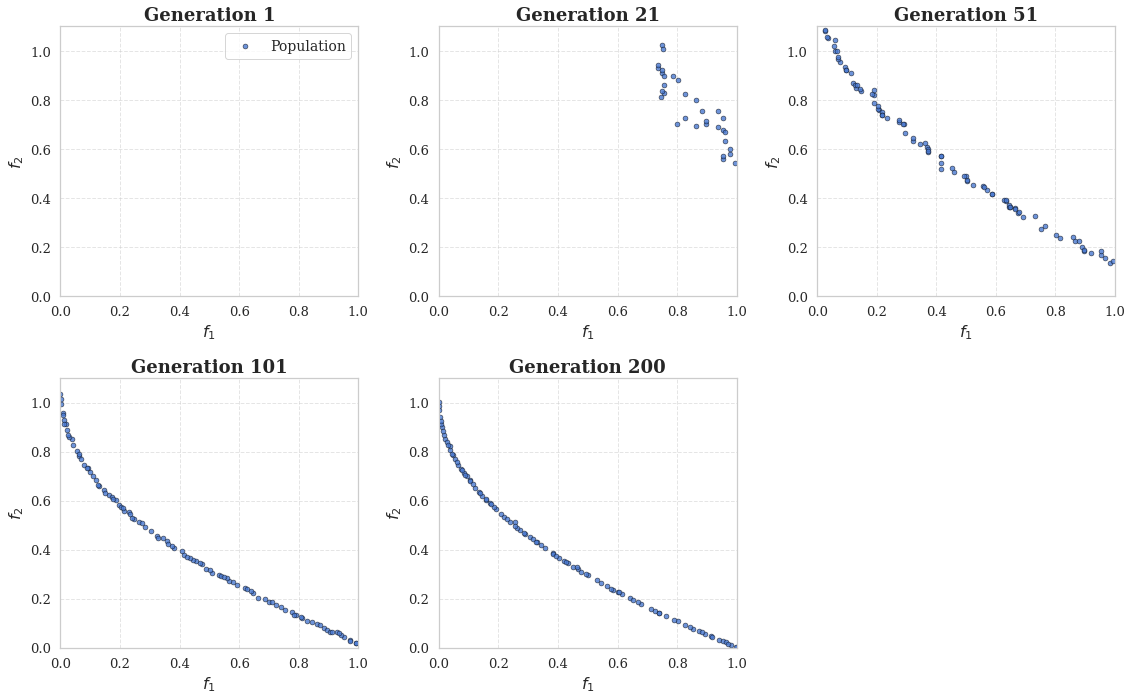

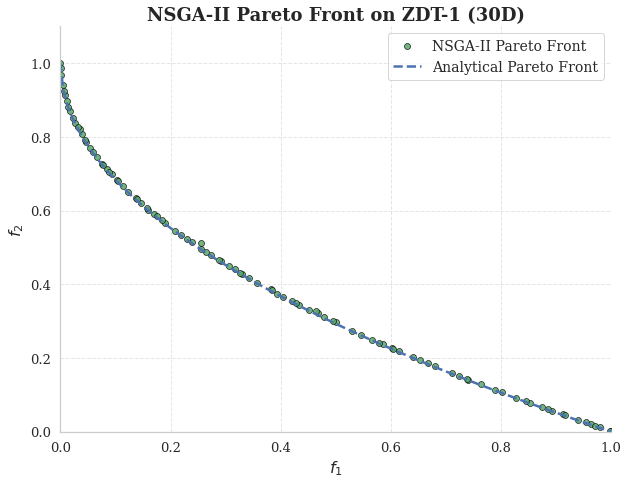

In [4]:

from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.problem import Problem
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.operators.sampling.rnd import FloatRandomSampling
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
import numpy as np

# 1. Define the ZDT-1 problem (30D) with vectorized evaluation
class ZDT1(Problem):
    def __init__(self, n_var=30):
        # Set elementwise_evaluation=False for vectorized evaluation
        super().__init__(n_var=n_var, n_obj=2, n_constr=0, xl=0.0, xu=1.0, elementwise_evaluation=False)

    def _evaluate(self, X, out, *args, **kwargs):
        # X is (N, n_var)
        f1 = X[:, 0]
        g = 1 + 9 * np.sum(X[:, 1:], axis=1) / (self.n_var - 1)
        h = 1 - np.sqrt(f1 / g)
        f2 = g * h
        out["F"] = np.column_stack([f1, f2])

problem = ZDT1(n_var=30)

# 2. Configure the NSGA-II algorithm
algorithm = NSGA2(
    pop_size=100,
    sampling=FloatRandomSampling(),
    crossover=SBX(prob=0.9, eta=15),
    mutation=PM(eta=20),
    eliminate_duplicates=True
)

# 3. Set the termination criterion (e.g., 200 generations)
termination = get_termination("n_gen", 200)

# 4. Run the optimization step-by-step
from pymoo.core.callback import Callback

class StepCallback(Callback):
    def __init__(self):
        super().__init__()
        self.history = []

    def notify(self, algorithm):
        # Store the current population's objective values
        self.history.append(algorithm.pop.get("F").copy())

callback = StepCallback()

# Run the optimization
res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    save_history=True,
    verbose=True,
    callback=callback
)

# 5. Step-by-step details: Show progress at selected generations (with styling)
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style for publication-quality plots
sns.set_context("notebook", font_scale=1.3)
sns.set_style("whitegrid")
plt.rcParams.update({
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "legend.fontsize": 14,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "figure.titlesize": 20,
    "font.family": "serif"
})

generations_to_plot = [0, 20, 50, 100, 199]  # 0-based indexing
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for i, gen in enumerate(generations_to_plot):
    F = callback.history[gen]
    ax = axes[i]
    ax.scatter(F[:, 0], F[:, 1], s=24, color=sns.color_palette("muted")[0], alpha=0.8, edgecolor='k', linewidth=0.5)
    ax.set_title(f'Generation {gen+1}', fontweight='bold')
    ax.set_xlabel(r'$f_1$', fontweight='bold')
    ax.set_ylabel(r'$f_2$', fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.1)
    if i == 0:
        ax.legend(['Population'], loc='upper right', frameon=True)
# Hide the last subplot if not used
if len(generations_to_plot) < len(axes):
    for j in range(len(generations_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# 6. Plot the final Pareto front (with styling)
plt.figure(figsize=(9, 7))
F = res.F
plt.scatter(F[:, 0], F[:, 1], s=36, color=sns.color_palette("deep")[2], label='NSGA-II Pareto Front', alpha=0.85, edgecolor='k', linewidth=0.7)
# Analytical Pareto front
f1_analytical = np.linspace(0, 1, 200)
f2_analytical = 1 - np.sqrt(f1_analytical)
plt.plot(f1_analytical, f2_analytical, color=sns.color_palette("deep")[0], linewidth=2.5, label='Analytical Pareto Front', linestyle='--')
plt.title('NSGA-II Pareto Front on ZDT-1 (30D)', fontweight='bold')
plt.xlabel(r'$f_1$', fontweight='bold')
plt.ylabel(r'$f_2$', fontweight='bold')
plt.legend(loc='upper right', frameon=True)
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(0, 1)
plt.ylim(0, 1.1)
sns.despine()
plt.tight_layout()
plt.show()


##### 2.2 NSGA-II without Crowding Distance Sorting Strategy

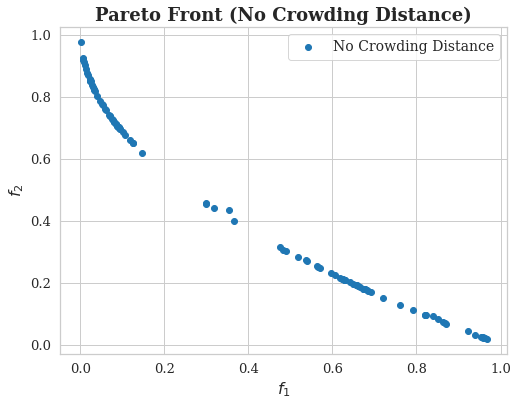

In [5]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.survival import Survival
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting
from pymoo.operators.selection.tournament import TournamentSelection
from pymoo.problems.multi.zdt import ZDT1
from pymoo.termination import get_termination
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
import numpy as np


# Custom survival: non-dominated sorting only
class NoCrowdingDistanceSurvival(Survival):
    def __init__(self):
        super().__init__(filter_infeasible=False)

    def _do(self, problem, pop, n_survive, **kwargs):
        F = pop.get("F")
        nds = NonDominatedSorting()
        fronts = nds.do(F, n_stop_if_ranked=n_survive)

        survivors = []
        for front in fronts:
            if len(survivors) + len(front) <= n_survive:
                survivors.extend(front)
            else:
                np.random.shuffle(front)
                survivors.extend(front[:n_survive - len(survivors)])
                break

        return pop[survivors]


# Custom random selection operator
class RandomSelection(TournamentSelection):
    def __init__(self):
        super().__init__(func_comp=self._rand_compare)

    def _rand_compare(self, pop, P, **kwargs):
        # P.shape = (n_tournaments, pressure)
        n = P.shape[0]
        choices = np.random.randint(0, P.shape[1], size=n)
        return P[np.arange(n), choices]


# Define problem
problem = ZDT1(n_var=30)

# Algorithm using custom survival and selection
algorithm = NSGA2(
    pop_size=100,
    survival=NoCrowdingDistanceSurvival(),
    selection=RandomSelection()
)

# Run optimizer
res = minimize(
    problem,
    algorithm,
    termination=get_termination("n_gen", 200),
    seed=1,
    verbose=False
)

from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

F_all = res.pop.get("F")
nds = NonDominatedSorting()
first_front = nds.do(F_all, only_non_dominated_front=True)

Scatter(title="Pareto Front (No Crowding Distance)", 
        xlabel="Objective 1", 
        ylabel="Objective 2", 
        legend=True, 
        color="navy", 
        alpha=0.8, 
        s=40, 
        marker="o").add(
    F_all[first_front], 
    label="No Crowding Distance"
).show()


#### 3 Optimize the Synchronous Buck Converter with Multi-Objective MHA
 * Objectives: Maximize efficiency, minimize volume, minimize cutoff frequency
 * Constraint: No constraint
 * Design variables: Inductance L and capacitance C values

##### 3.1 Define Performance Targets Considered

In [6]:
import numpy as np
import pyswarms as ps
import matplotlib.pyplot as plt
from matplotlib import animation

def buck_converter_losses(L, C, Io, inductanceR, capacitorR):
    """
    Calculate various losses and parameters for a synchronous buck converter.

    Parameters:
    - L: Inductance (H)
    - C: Capacitance (F)
    - Io: Output current (A)
    - inductanceR: function, returns copper resistance of inductor given L
    - capacitorR: function, returns ESR of capacitor given C, Vo

    Returns:
    - dict of all calculated losses and key parameters
    """
    import numpy as np
    from scipy.integrate import quad

    # Define key parameters for the synchronous buck converter
    f = 1e4            # Switching frequency (Hz)
    QG = 62e-9         # Gate charge (Coulombs)
    Vgs = 20           # Gate-source voltage (V)
    Coss = 475e-12     # Output capacitance of MOSFET (Farads)
    Vin = 100          # Input voltage (V)
    Vds = Vin          # Drain-source voltage (V)
    Ron = 75e-3        # On-resistance of MOSFET (Ohms)
    Vo = 50            # Output voltage (V)

    # Inductor geometry parameters
    OD = 28.6e-3       # Outer diameter of inductor (meters)
    ID = 11.8e-3       # Inner diameter of inductor (meters)
    H = 10e-3          # Height of inductor (meters)
    ur = 49            # Relative permeability of core material

    # Calculate effective core volume and area
    Ve = (38.92*L*1e6+264.3)*1e-3           # Effective core volume (m^3)
    AeN = (13.26*L*1e6+1008)*1e-9*1e3/0.6   # Effective core area (m^2)
    Ro = Vo/Io

    # Steinmetz parameters for core loss calculation
    kc = 3.961*1e-9
    afa = 1.214
    beta = 2.013

    # Calculate copper resistance of the inductor
    DCR = inductanceR(L)
    Rcopper = DCR

    # MOSFET switching times
    tr = 37e-9
    tf = 38e-9

    # Mosfet reverse recovery charge (for reverse recovery loss)
    Qcoss = 152e-9
    Qrr = 152e-9  # Example value, adjust as needed

    # Capacitor equivalent series resistance
    ESR = capacitorR(C, f)

    # Calculate the duty cycle
    D = Vo/Vin * (1+Rcopper/Ro)

    # Calculate intermediate variables
    A = (Vin-Vo)/Rcopper
    B = Vo/Rcopper
    E = np.exp(-Rcopper/L*D/f)

    # Calculate the inductor current
    # (as in the original code)
    ILmin = 2*Io/(1+E)-A*(1-E)/(1+E)
    ILmax = 2*Io-ILmin

    # t1, t2 for integration limits
    try:
        t1 = -L/DCR * np.log((Io-A)/(ILmin-A))
    except:
        t1 = 0
    try:
        t2 = -L/DCR * np.log((Io+B)/(ILmax+B))
    except:
        t2 = 0

    # Define integrands for INTEGRALL, INTEGRALL2, INTEGRALL3
    def integrand1a(x):
        return A**2 + 2*A*(ILmin-A)*np.exp(-DCR/L*x) + (ILmin-A)**2 * np.exp(-2*DCR/L*x)
    def integrand1b(x):
        return B**2 - 2*B*(ILmax+B)*np.exp(-DCR/L*x) + (ILmax+B)**2 * np.exp(-2*DCR/L*x)
    def integrand2a(x):
        return A + (ILmin-A)*np.exp(-DCR/L*x)
    def integrand2b(x):
        return -B + (ILmax+B)*np.exp(-DCR/L*x)
    def integrand3a(x):
        return A + (ILmin-A)*np.exp(-DCR/L*x)
    def integrand3b(x):
        return -B + (ILmax+B)*np.exp(-DCR/L*x)

    # Perform integrations
    INTEGRALL, _ = quad(integrand1a, 0, D/f)
    temp, _ = quad(integrand1b, 0, (1-D)/f)
    INTEGRALL += temp

    INTEGRALL2, _ = quad(integrand2a, 0, D/f)
    temp, _ = quad(integrand2b, 0, (1-D)/f)
    INTEGRALL2 += temp

    INTEGRALL3, _ = quad(integrand3a, t1, D/f)
    temp, _ = quad(integrand3b, 0, t2)
    INTEGRALL3 += temp

    # 1. Gate drive loss
    Pdr = QG * Vgs * f

    # 2. Output capacitance loss of MOSFET
    Pcoss = 0.5 * Coss * Vds**2 * f

    # 3. Conduction loss of MOSFET
    Pon = Ron * f * INTEGRALL

    # 4. Inductor current ripple
    deltaI = ILmax - ILmin

    # 5. Core flux density swing
    deltaB = L * deltaI / AeN

    # 6. Steinmetz equation for core loss
    ki = kc * 2**(-beta-1) * np.pi**(1-afa) / (0.2761 + 1.7061 / (1.354 + afa))
    Pfe = ki * (deltaB*1e4)**beta * f**afa * (D**(1-afa) + (1-D)**(1-afa)) * Ve * 1e-3

    # 7. Copper loss in the inductor
    Pcu = DCR * f * INTEGRALL

    # 8. Minimum and maximum inductor current (already calculated above)

    # 9. MOSFET switching losses
    Pswitchon = 0.5*Vin * Io * tr * f
    Pswitchoff = 0.5*Vin * Io * tf * f

    # 9b. Reverse recovery loss
    Prr = Qrr * Vds * f

    # 10. Capacitor ESR loss
    PC = ESR * f * INTEGRALL - ESR * f * 2 * Io * INTEGRALL2 + ESR * Io**2

    # 11. Total power loss (add Prr)
    Ptotal = 2*Pdr + Pon + Pfe + Pcu + Pswitchon + Pswitchoff + Prr + PC

    # Voltage ripple and current ripple
    voltageripple = ((INTEGRALL3 - Io * (t2 + D/f - t1)) / C + ESR * deltaI) / Vo
    currentripple = deltaI / Io

    return {
        'Pdr': Pdr,
        'Pcoss': Pcoss,
        'Pon': Pon,
        'deltaI': deltaI,
        'deltaB': deltaB,
        'Pfe': Pfe,
        'Pcu': Pcu,
        'ILmin': ILmin,
        'ILmax': ILmax,
        'Pswitchon': Pswitchon,
        'Pswitchoff': Pswitchoff,
        'Prr': Prr,
        'PC': PC,
        'Ptotal': Ptotal,
        'N': None,
        'Ve': Ve,
        'Rcopper': Rcopper,
        'ESR': ESR,
        'D': D,
        'Vo': Vo,
        'Vin': Vin,
        'f': f,
        'voltageripple': voltageripple,
        'currentripple': currentripple
    }

def evaluate_LC_volume(L, C):
    """
    Evaluate the total volume of inductor (L) and capacitor (C).

    Parameters:
    L (float): Inductance in Henrys
    C (float): Capacitance in Farads

    Returns:
    float: Total volume (y) in mm^3
    """
    a_C = 5.909
    b_C = 0
    a_L = 38.92
    b_L = 264.3

    VC = a_C * C * 1e6 + b_C
    VL = a_L * L * 1e6 + b_L
    y = VC + VL
    return y

def cutoff_freq(L, C):
    return 1/2/np.pi/np.sqrt(L*C)

# Define dummy functions for inductor copper resistance and capacitor ESR
def inductanceR(L):
    # Example: assume copper resistance is proportional to sqrt(L)
    return 1183*L+0.01034

def capacitorR(C, f):
    # Example: assume ESR is inversely proportional to C
    return 1.5 / (2 * np.pi * f * C)

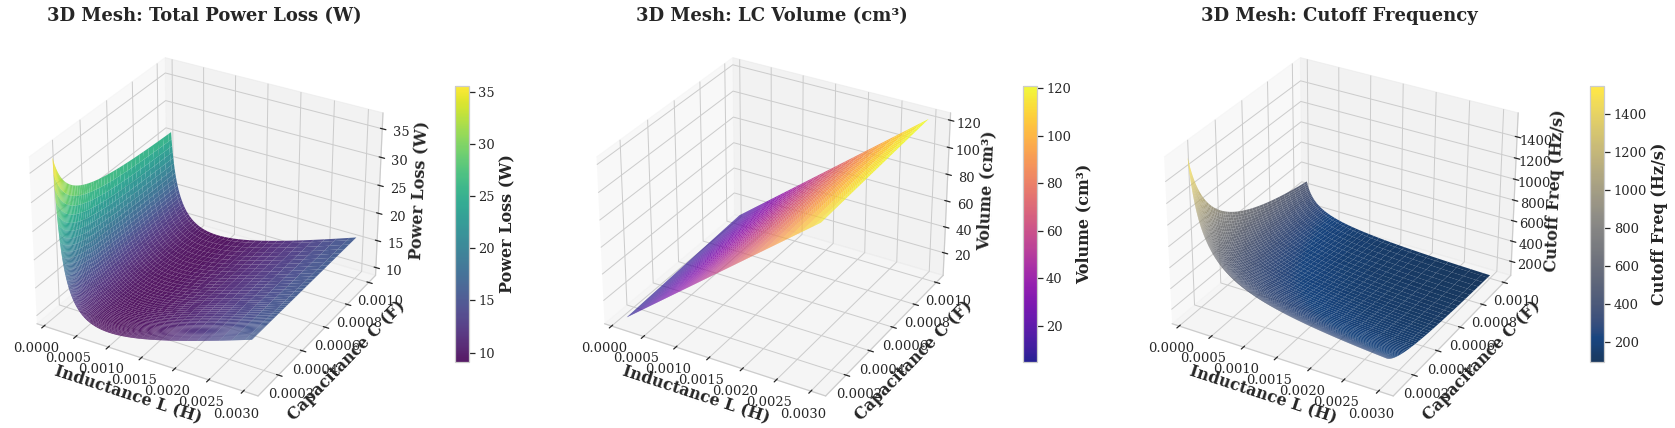

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Define the ranges for L and C
L_vals = np.logspace(np.log10(100e-6), np.log10(3e-3), 100)
C_vals = np.logspace(np.log10(100e-6), np.log10(1e-3), 100)
L_grid, C_grid = np.meshgrid(L_vals, C_vals)

Io = 2  # Output current in A

Ptotal_grid = np.zeros_like(L_grid)
Volume_grid = np.zeros_like(L_grid)

for i in range(L_grid.shape[0]):
    for j in range(L_grid.shape[1]):
        L = L_grid[i, j]
        C = C_grid[i, j]
        try:
            result = buck_converter_losses(L, C, Io, inductanceR, capacitorR)
            Ptotal_grid[i, j] = result['Ptotal']
        except Exception:
            Ptotal_grid[i, j] = np.nan
        try:
            Volume_grid[i, j] = evaluate_LC_volume(L, C)
        except Exception:
            Volume_grid[i, j] = np.nan

# Plot the function landscapes as 2D surface plots with colorbars (no log scale for L and C)

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Assume L_grid, C_grid, Ptotal_grid, Volume_grid are defined earlier

fig = plt.figure(figsize=(24, 6))

# 3D Mesh for Total Power Loss
ax1 = fig.add_subplot(1, 3, 1, projection='3d')
surf1 = ax1.plot_surface(L_grid, C_grid, Ptotal_grid, cmap='viridis', edgecolor='none', alpha=0.9)
ax1.set_xlabel('Inductance L (H)')
ax1.set_ylabel('Capacitance C (F)')
ax1.set_zlabel('Power Loss (W)')
ax1.set_title('3D Mesh: Total Power Loss (W)')
fig.colorbar(surf1, ax=ax1, shrink=0.7, pad=0.1, label='Power Loss (W)')

# 3D Mesh for Volume
ax2 = fig.add_subplot(1, 3, 2, projection='3d')
# Convert Volume_grid from mm³ to cm³ (1 cm³ = 1000 mm³)
Volume_grid_cm3 = Volume_grid / 1000.0
surf2 = ax2.plot_surface(L_grid, C_grid, Volume_grid_cm3, cmap='plasma', edgecolor='none', alpha=0.9)
ax2.set_xlabel('Inductance L (H)')
ax2.set_ylabel('Capacitance C (F)')
ax2.set_zlabel('Volume (cm³)')
ax2.set_title('3D Mesh: LC Volume (cm³)')
fig.colorbar(surf2, ax=ax2, shrink=0.7, pad=0.1, label='Volume (cm³)')

# 3D Mesh for Cutoff Frequency
ax3 = fig.add_subplot(1, 3, 3, projection='3d')
# Calculate cutoff frequency grid
omega_c_grid = cutoff_freq(L_grid, C_grid)
surf3 = ax3.plot_surface(L_grid, C_grid, omega_c_grid, cmap='cividis', edgecolor='none', alpha=0.9)
ax3.set_xlabel('Inductance L (H)')
ax3.set_ylabel('Capacitance C (F)')
ax3.set_zlabel('Cutoff Freq (Hz/s)')
ax3.set_title('3D Mesh: Cutoff Frequency')
fig.colorbar(surf3, ax=ax3, shrink=0.7, pad=0.1, label='Cutoff Freq (Hz/s)')

plt.tight_layout()
plt.show()




##### 3.2 Define Objective Functions for NSGA-II Algorithm

In [8]:
from pymoo.core.problem import Problem

class BuckConverterNSGA2Problem(Problem):
    def __init__(self, Io=2.0):
        # Decision variables: L (H), C (F)
        # Bounds: L in [10e-6, 100e-6], C in [100e-6, 1000e-6]
        super().__init__(
            n_var=2,
            n_obj=3,
            n_constr=0,
            xl=np.array([100e-6, 100e-6]),
            xu=np.array([3000e-6, 2000e-6])
        )
        self.Io = Io

    def _evaluate(self, X, out, *args, **kwargs):
        # X: (n_samples, 2) array, columns: L, C
        F = np.zeros((X.shape[0], 3))
        for i, (L, C) in enumerate(X):
            # Calculate losses and volume
            losses = buck_converter_losses(L, C, self.Io, inductanceR, capacitorR)
            volume = evaluate_LC_volume(L, C)
            F[i, 0] = losses['Ptotal']  # Objective 1: Total power loss (W)
            F[i, 1] = volume/1000            # Objective 2: Total volume (cm^3)
            F[i, 2] = cutoff_freq(L, C) # Objective 3: Cutoff frequency (Hz)
        out["F"] = F

# Example usage:
problem = BuckConverterNSGA2Problem(Io=2.0)
problem.evaluate(np.array([[100e-6, 3000e-6], [100e-6, 2000e-6]]))

array([[ 25.15624754,  21.8833    , 290.57584157],
       [ 25.36338387,  15.9743    , 355.88127171]])

##### 3.3 Implement NSGA-II Algorithm

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |      200 |     82 |             - |             -
     2 |      400 |    125 |  0.0040648435 |         ideal
     3 |      600 |    186 |  0.0108897505 |         ideal
     4 |      800 |    200 |  0.0646606110 |         nadir
     5 |     1000 |    200 |  0.0899763399 |         nadir
     6 |     1200 |    200 |  0.0685387050 |         nadir
     7 |     1400 |    200 |  0.0508177007 |         nadir
     8 |     1600 |    200 |  0.0125377598 |         nadir
     9 |     1800 |    200 |  0.0075956590 |             f
    10 |     2000 |    200 |  0.0201764663 |         nadir
    11 |     2200 |    200 |  0.0051128629 |             f
    12 |     2400 |    200 |  0.0111507062 |         nadir
    13 |     2600 |    200 |  0.0068340299 |         nadir
    14 |     2800 |    200 |  0.0050065792 |         nadir
    15 |     3000 |    200 |  0.0077184922 |             f
    16 |     3200 |    200 |  0.0049449312 |            

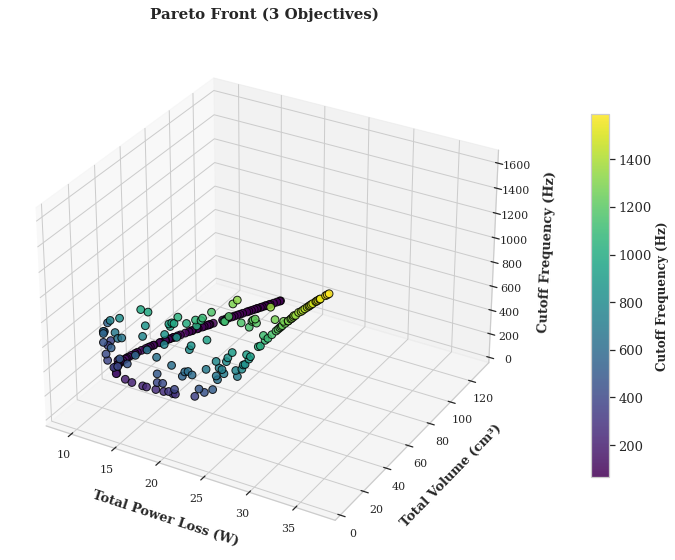

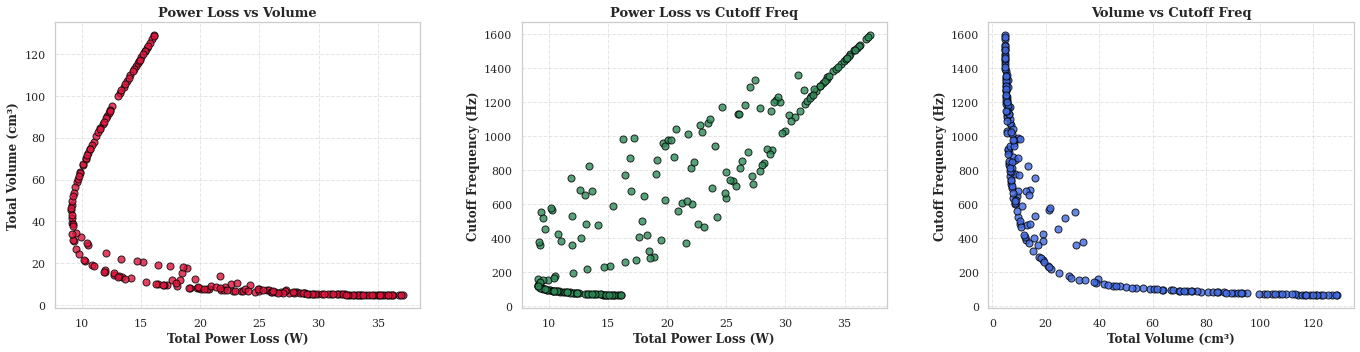

In [ ]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.termination import get_termination
from pymoo.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

# Set up the NSGA-II algorithm
algorithm = NSGA2(
    pop_size=200,
)

# Set up the termination criterion
termination = get_termination("n_gen", 200)

# Run the optimization
res = minimize(
    problem,
    algorithm,
    termination,
    seed=1,
    save_history=True,
    verbose=True
)

# Show the results
print("Best solutions (first 5):")
print(res.X[:5])
print("Objective values (first 5):")
print(res.F[:5])

# Plot the Pareto front in 3D with enhanced styling
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(
    res.F[:,0], res.F[:,1], res.F[:,2],
    c=res.F[:,2], cmap='viridis', marker='o', alpha=0.85, edgecolor='k', s=60
)
ax.set_xlabel('Total Power Loss (W)', fontsize=13, labelpad=12, fontweight='bold')
ax.set_ylabel('Total Volume (cm³)', fontsize=13, labelpad=12, fontweight='bold')
ax.set_zlabel('Cutoff Frequency (Hz)', fontsize=13, labelpad=12, fontweight='bold')
ax.set_title('Pareto Front (3 Objectives)', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Cutoff Frequency (Hz)', fontsize=12)
plt.tight_layout()
plt.show()

# Plot 2D projections with enhanced styling
fig, axs = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')

axs[0].scatter(res.F[:,0], res.F[:,1], c='crimson', alpha=0.8, edgecolor='k', s=50)
axs[0].set_xlabel('Total Power Loss (W)', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Total Volume (cm³)', fontsize=12, fontweight='bold')
axs[0].set_title('Power Loss vs Volume', fontsize=13, fontweight='bold')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].tick_params(axis='both', which='major', labelsize=11)

axs[1].scatter(res.F[:,0], res.F[:,2], c='seagreen', alpha=0.8, edgecolor='k', s=50)
axs[1].set_xlabel('Total Power Loss (W)', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Cutoff Frequency (Hz)', fontsize=12, fontweight='bold')
axs[1].set_title('Power Loss vs Cutoff Freq', fontsize=13, fontweight='bold')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].tick_params(axis='both', which='major', labelsize=11)

axs[2].scatter(res.F[:,1], res.F[:,2], c='royalblue', alpha=0.8, edgecolor='k', s=50)
axs[2].set_xlabel('Total Volume (cm³)', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Cutoff Frequency (Hz)', fontsize=12, fontweight='bold')
axs[2].set_title('Volume vs Cutoff Freq', fontsize=13, fontweight='bold')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].tick_params(axis='both', which='major', labelsize=11)

plt.tight_layout(pad=3.0)
plt.show()


##### 3.4 Fetch Designs from Pareto Front

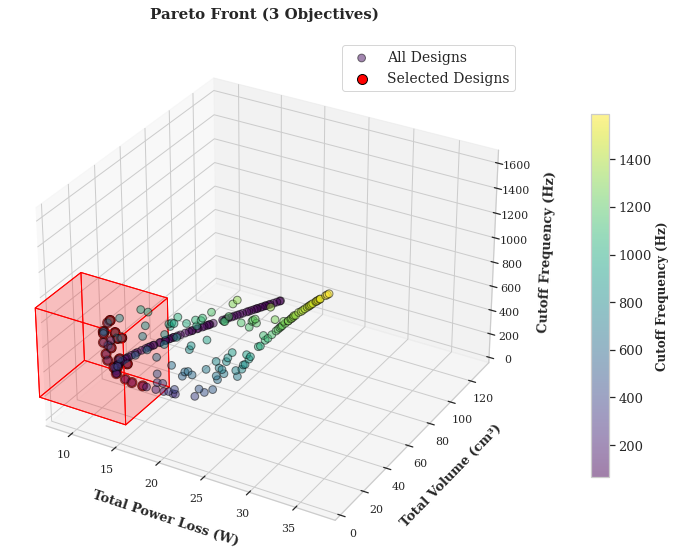

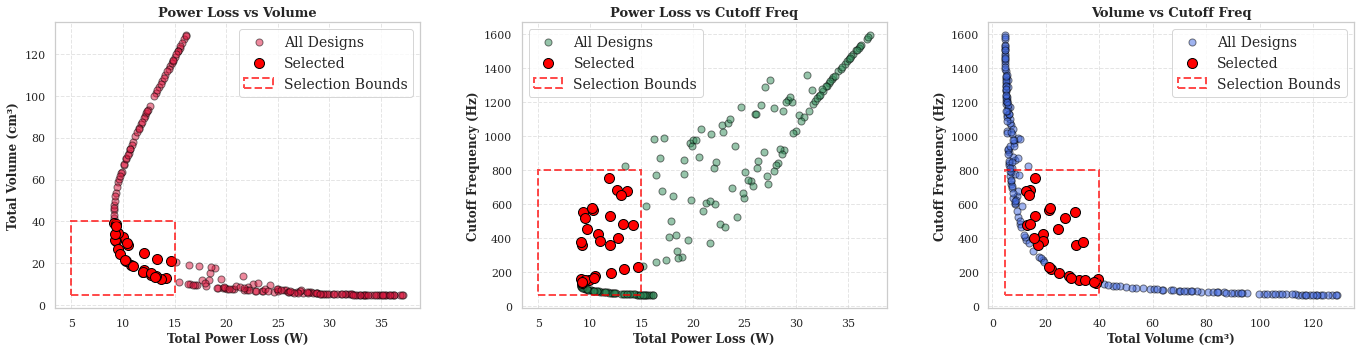

,Total Power Loss (W),Total Volume (cm³),Cutoff Frequency (Hz)
0,9.951551,32.354990,155.932276
1,10.508217,28.527203,175.986084
2,9.119270,39.430537,162.074722
3,11.940574,15.796790,532.169900
4,9.331499,30.860012,552.590581
5,9.230752,31.345281,358.673222
6,13.276244,22.083254,221.238207
7,9.492731,34.652690,152.345623
8,9.282526,38.700788,136.088774
9,9.509900,27.010551,517.151482


In [10]:
import pandas as pd

# Allow None in the ranges: if a bound is None, it is not applied
# Example: (None, 30) means no lower bound, upper bound 30
power_loss_range = (5, 15)         # (min, max) or (None, max) or (min, None) or (None, None)
volume_range = (None, 40)
cutoff_freq_range = (None, 800)

def in_range(arr, bounds):
    """Return boolean mask for arr within bounds (None allowed)."""
    mask = np.ones_like(arr, dtype=bool)
    if bounds[0] is not None:
        mask &= arr >= bounds[0]
    if bounds[1] is not None:
        mask &= arr <= bounds[1]
    return mask

# Get the min/max of the Pareto front for each objective
F = res.F
frontier_limits = {
    0: (F[:,0].min(), F[:,0].max()),
    1: (F[:,1].min(), F[:,1].max()),
    2: (F[:,2].min(), F[:,2].max())
}

def fill_none_bounds(bounds, limits):
    """Replace None in bounds with the corresponding min/max from limits."""
    return (
        limits[0] if bounds[0] is None else bounds[0],
        limits[1] if bounds[1] is None else bounds[1]
    )

# Find indices of designs within the specified ranges (with None support)
mask0 = in_range(F[:,0], power_loss_range)
mask1 = in_range(F[:,1], volume_range)
mask2 = in_range(F[:,2], cutoff_freq_range)
selected_idx = np.where(mask0 & mask1 & mask2)[0]

# Plot the Pareto front in 3D with enhanced styling and highlight selected designs
fig = plt.figure(figsize=(10, 8), facecolor='white')
ax = fig.add_subplot(111, projection='3d')
# Plot all points
sc = ax.scatter(
    F[:,0], F[:,1], F[:,2],
    c=F[:,2], cmap='viridis', marker='o', alpha=0.5, edgecolor='k', s=60, label='All Designs'
)
# Highlight selected points
if len(selected_idx) > 0:
    ax.scatter(
        F[selected_idx,0], F[selected_idx,1], F[selected_idx,2],
        c='red', marker='o', edgecolor='k', s=100, label='Selected Designs'
    )

# Plot the selection bounds as a translucent box, filling None with frontier limits
def plot_selection_box(ax, x_range, y_range, z_range, color='red', alpha=0.12):
    from mpl_toolkits.mplot3d.art3d import Poly3DCollection
    x_min, x_max = x_range
    y_min, y_max = y_range
    z_min, z_max = z_range
    # Vertices of the box
    verts = [
        [x_min, y_min, z_min],
        [x_max, y_min, z_min],
        [x_max, y_max, z_min],
        [x_min, y_max, z_min],
        [x_min, y_min, z_max],
        [x_max, y_min, z_max],
        [x_max, y_max, z_max],
        [x_min, y_max, z_max]
    ]
    # 6 faces
    faces = [
        [verts[0], verts[1], verts[2], verts[3]], # bottom
        [verts[4], verts[5], verts[6], verts[7]], # top
        [verts[0], verts[1], verts[5], verts[4]], # front
        [verts[2], verts[3], verts[7], verts[6]], # back
        [verts[1], verts[2], verts[6], verts[5]], # right
        [verts[4], verts[7], verts[3], verts[0]], # left
    ]
    box = Poly3DCollection(faces, facecolors=color, alpha=alpha, linewidths=1, edgecolors=color)
    ax.add_collection3d(box)

# Fill None in ranges with frontier limits for plotting
x_box = fill_none_bounds(power_loss_range, frontier_limits[0])
y_box = fill_none_bounds(volume_range, frontier_limits[1])
z_box = fill_none_bounds(cutoff_freq_range, frontier_limits[2])
plot_selection_box(ax, x_box, y_box, z_box, color='red', alpha=0.12)

ax.set_xlabel('Total Power Loss (W)', fontsize=13, labelpad=12, fontweight='bold')
ax.set_ylabel('Total Volume (cm³)', fontsize=13, labelpad=12, fontweight='bold')
ax.set_zlabel('Cutoff Frequency (Hz)', fontsize=13, labelpad=12, fontweight='bold')
ax.set_title('Pareto Front (3 Objectives)', fontsize=15, fontweight='bold', pad=20)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.grid(True, linestyle='--', alpha=0.5)
cbar = fig.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label('Cutoff Frequency (Hz)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2D projections with enhanced styling and highlight selected designs
fig, axs = plt.subplots(1, 3, figsize=(20, 6), facecolor='white')

# Power Loss vs Volume
axs[0].scatter(F[:,0], F[:,1], c='crimson', alpha=0.5, edgecolor='k', s=50, label='All Designs')
if len(selected_idx) > 0:
    axs[0].scatter(F[selected_idx,0], F[selected_idx,1], c='red', edgecolor='k', s=100, label='Selected')
# Plot bounds as rectangle, filling None with frontier limits
x0, x1 = fill_none_bounds(power_loss_range, frontier_limits[0])
y0, y1 = fill_none_bounds(volume_range, frontier_limits[1])
rect = plt.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--', alpha=0.7, label='Selection Bounds'
)
axs[0].add_patch(rect)
axs[0].set_xlabel('Total Power Loss (W)', fontsize=12, fontweight='bold')
axs[0].set_ylabel('Total Volume (cm³)', fontsize=12, fontweight='bold')
axs[0].set_title('Power Loss vs Volume', fontsize=13, fontweight='bold')
axs[0].grid(True, linestyle='--', alpha=0.5)
axs[0].tick_params(axis='both', which='major', labelsize=11)
axs[0].legend()

# Power Loss vs Cutoff Freq
axs[1].scatter(F[:,0], F[:,2], c='seagreen', alpha=0.5, edgecolor='k', s=50, label='All Designs')
if len(selected_idx) > 0:
    axs[1].scatter(F[selected_idx,0], F[selected_idx,2], c='red', edgecolor='k', s=100, label='Selected')
x0, x1 = fill_none_bounds(power_loss_range, frontier_limits[0])
y0, y1 = fill_none_bounds(cutoff_freq_range, frontier_limits[2])
rect = plt.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--', alpha=0.7, label='Selection Bounds'
)
axs[1].add_patch(rect)
axs[1].set_xlabel('Total Power Loss (W)', fontsize=12, fontweight='bold')
axs[1].set_ylabel('Cutoff Frequency (Hz)', fontsize=12, fontweight='bold')
axs[1].set_title('Power Loss vs Cutoff Freq', fontsize=13, fontweight='bold')
axs[1].grid(True, linestyle='--', alpha=0.5)
axs[1].tick_params(axis='both', which='major', labelsize=11)
axs[1].legend()

# Volume vs Cutoff Freq
axs[2].scatter(F[:,1], F[:,2], c='royalblue', alpha=0.5, edgecolor='k', s=50, label='All Designs')
if len(selected_idx) > 0:
    axs[2].scatter(F[selected_idx,1], F[selected_idx,2], c='red', edgecolor='k', s=100, label='Selected')
x0, x1 = fill_none_bounds(volume_range, frontier_limits[1])
y0, y1 = fill_none_bounds(cutoff_freq_range, frontier_limits[2])
rect = plt.Rectangle(
    (x0, y0),
    x1 - x0,
    y1 - y0,
    linewidth=2, edgecolor='red', facecolor='none', linestyle='--', alpha=0.7, label='Selection Bounds'
)
axs[2].add_patch(rect)
axs[2].set_xlabel('Total Volume (cm³)', fontsize=12, fontweight='bold')
axs[2].set_ylabel('Cutoff Frequency (Hz)', fontsize=12, fontweight='bold')
axs[2].set_title('Volume vs Cutoff Freq', fontsize=13, fontweight='bold')
axs[2].grid(True, linestyle='--', alpha=0.5)
axs[2].tick_params(axis='both', which='major', labelsize=11)
axs[2].legend()

plt.tight_layout(pad=3.0)
plt.show()

# Show the list of selected designs in a table
if len(selected_idx) > 0:
    selected_designs = F[selected_idx]
    df_selected = pd.DataFrame(selected_designs, columns=['Total Power Loss (W)', 'Total Volume (cm³)', 'Cutoff Frequency (Hz)'])
    display(df_selected)
else:
    print("No designs found within the specified ranges.")